# Proyek Akhir Machine Learning Terapan: Sistem Rekomendasi Buku
Oleh: Muhammad iqbal Saputra



## 1. Persiapan Workspace dan Import Library
Tahap ini digunakan untuk mengimpor seluruh pustaka yang dibutuhkan serta mengunduh dataset langsung dari Kaggle menggunakan API.

In [1]:
# Import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk Content-Based Filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Import library untuk Collaborative Filtering
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Mengunggah file kaggle.json
from google.colab import files
print("Silakan unggah file kaggle.json Anda:")
uploaded = files.upload()

# Mengunduh dataset menggunakan Kaggle API
# Pastikan Anda sudah mengunggah file kaggle.json ke sesi Colab
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d arashnic/book-recommendation-dataset
!unzip -q book-recommendation-dataset.zip -d dataset

Silakan unggah file kaggle.json Anda:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset
License(s): CC0-1.0
100% 24.3M/24.3M [00:00<00:00, 68.0MB/s]



## 2. Data Understanding
Memuat data dari berkas CSV ke dalam Pandas DataFrame untuk melihat struktur data, jumlah baris, dan fitur yang tersedia. Dataset terdiri dari data Buku, Rating, dan Pengguna.

In [2]:
# Memuat data
books = pd.read_csv('dataset/Books.csv', low_memory=False)
ratings = pd.read_csv('dataset/Ratings.csv')
users = pd.read_csv('dataset/Users.csv')

print(f"Jumlah baris data Buku: {len(books)}")
print(f"Jumlah baris data Rating: {len(ratings)}")
print(f"Jumlah baris data Pengguna: {len(users)}")

print("\nStruktur data Buku: \n")
display(books.head(3))
print("\nStruktur data Rating: \n")
display(ratings.head(3))
print("\nStruktur data Pengguna: \n")
display(users.head(3))

Jumlah baris data Buku: 271360
Jumlah baris data Rating: 1149780
Jumlah baris data Pengguna: 278858

Struktur data Buku: 



,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...



Struktur data Rating: 



,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0



Struktur data Pengguna: 



,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN


## 3. Exploratory Data Analysis (EDA)
Melihat distribusi rating yang diberikan oleh pengguna untuk memahami tendensi penilaian secara umum.

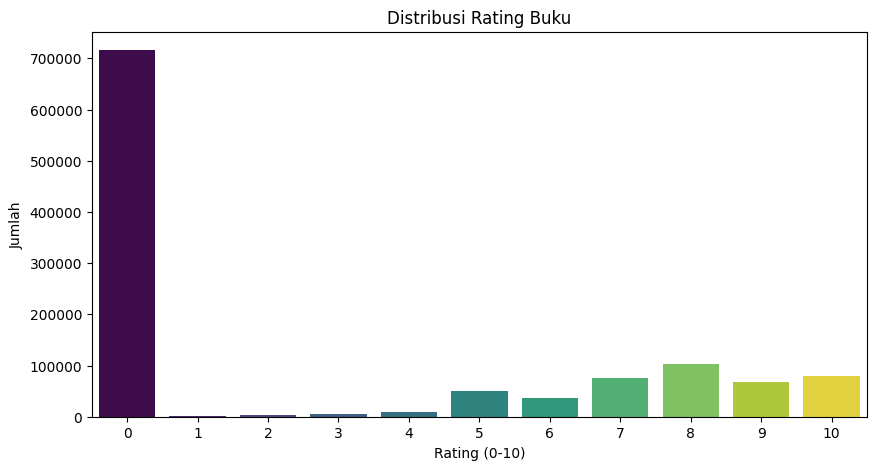

In [3]:
plt.figure(figsize=(10, 5))

sns.countplot(x='Book-Rating', data=ratings, hue='Book-Rating', palette='viridis', legend=False)

plt.title('Distribusi Rating Buku')
plt.xlabel('Rating (0-10)')
plt.ylabel('Jumlah')
plt.show()

## 4. Data Preparation
Tahapan ini meliputi pembersihan data, penggabungan dataset, penanganan _missing values_, serta _subsetting_ agar komputasi tidak mengalami _Out of Memory_ (RAM _crash_) saat melatih model.

In [4]:
# Menghapus kolom URL gambar yang tidak relevan untuk pemodelan
books_clean = books.drop(columns=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'])

# Hanya mengambil rating eksplisit (Rating > 0)
ratings_explicit = ratings[ratings['Book-Rating'] > 0]

# Menggabungkan data rating dan buku berdasarkan ISBN
df_merged = ratings_explicit.merge(books_clean, on='ISBN', how='inner')

# Pengecekan jumlah baris dan kolom
print("Bentuk data books:", books.shape)
print("Bentuk data ratings:", ratings.shape)
print("Bentuk data users:", users.shape)

# Pengecekan Missing Value tiap dataset
print("\nMissing Value Books:\n", books.isnull().sum())
print("\nMissing Value Ratings:\n", ratings.isnull().sum())
print("\nMissing Value Users:\n", users.isnull().sum())

# Pengecekan Duplikat tiap dataset
print("\nDuplikat Books:", books.duplicated().sum())
print("Duplikat Ratings:", ratings.duplicated().sum())
print("Duplikat Users:", users.duplicated().sum())

# lakukan dropna
df_merged = df_merged.dropna()

# Mengambil sampel 10.000 data secara acak untuk efisiensi memori (opsional namun sangat disarankan)
df = df_merged.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Jumlah data setelah proses preparation: {len(df)}")
display(df.head(3))

Bentuk data books: (271360, 8)
Bentuk data ratings: (1149780, 3)
Bentuk data users: (278858, 3)

Missing Value Books:
 ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Missing Value Ratings:
 User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Missing Value Users:
 User-ID          0
Location         0
Age         110762
dtype: int64

Duplikat Books: 0
Duplikat Ratings: 0
Duplikat Users: 0
Jumlah data setelah proses preparation: 10000


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,167678,0140244816,8,What's A Girl Gotta Do,Sparkle Hayter,1995,Penguin Books
1,171118,0140218963,8,"Apes, Men and Language (Pelican S.)",Eugene Linden,1976,Penguin Books Ltd
2,106893,1843337045,7,Fairy Paths &amp; Spirit Roads: Exploring Othe...,Paul Devereux,2003,Vega Books


## 5. Model Development: Content-Based Filtering
Membangun sistem rekomendasi berdasarkan kemiripan nama Penulis (Author). Buku yang ditulis oleh penulis yang sama atau memiliki gaya penulisan serupa akan direkomendasikan. Algoritma yang digunakan adalah TF-IDF Vectorizer dan Cosine Similarity.

In [5]:
# Mempersiapkan dataframe khusus untuk Content-Based
preparation = df.drop_duplicates('ISBN').reset_index(drop=True)

# Inisialisasi TfidfVectorizer
tfidf = TfidfVectorizer()

# Melakukan perhitungan idf pada data Book-Author
tfidf_matrix = tfidf.fit_transform(preparation['Book-Author'])

# Menghitung Cosine Similarity pada matriks tf-idf
cosine_sim = cosine_similarity(tfidf_matrix)

# Membuat dataframe similarity
cosine_sim_df = pd.DataFrame(cosine_sim, index=preparation['Book-Title'], columns=preparation['Book-Title'])

# Fungsi untuk mendapatkan rekomendasi Top-N
def book_recommendations(nama_buku, similarity_data=cosine_sim_df, items=preparation[['Book-Title', 'Book-Author', 'Publisher']], k=5):
    # Mengambil data dengan similarity tertinggi dari index
    index = similarity_data.loc[:,nama_buku].to_numpy().argpartition(range(-1, -k-1, -1))

    # Mengambil data dengan similarity terbesar
    closest = similarity_data.columns[index[-1:-(k+2):-1]]

    # Drop nama_buku agar tidak merekomendasikan buku yang sama
    closest = closest.drop(nama_buku, errors='ignore')

    return pd.DataFrame(closest).merge(items).drop_duplicates().head(k)

# Menguji Model Content-Based
sample_book = preparation['Book-Title'].iloc[10]
print(f"Rekomendasi untuk buku: {sample_book} (Penulis: {preparation[preparation['Book-Title'] == sample_book]['Book-Author'].values[0]})")
display(book_recommendations(sample_book))

Rekomendasi untuk buku: American Dreams: Lost and Found (Penulis: Studs Terkel)


,Book-Title,Book-Author,Publisher
0,Race,STUDS TERKEL,Anchor
1,"Arrow's Fall (The Heralds of Valdemar, Book 3)",Mercedes Lackey,Daw Books
2,Surviavlist #9 Earth Fire,Jerry Ahern,Zebra Books
3,The Engines of God,Jack McDevitt,Ace Books
4,"Wizard and Glass (The Dark Tower, Book 4)",Stephen King,Plume Books


## 6. Model Development: Collaborative Filtering
Merekomendasikan buku berdasarkan pola histori interaksi *user-item*. Menggunakan *Deep Learning* dengan *Embedding Layer* untuk mengkalkulasi kecocokan antarpengguna.

In [6]:
# Menyalin data
df_collab = df.copy()

# Encoding User-ID
user_ids = df_collab['User-ID'].unique().tolist()
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
df_collab['user'] = df_collab['User-ID'].map(user_to_user_encoded)

# Encoding ISBN
book_ids = df_collab['ISBN'].unique().tolist()
book_to_book_encoded = {x: i for i, x in enumerate(book_ids)}
book_encoded_to_book = {i: x for i, x in enumerate(book_ids)}
df_collab['book'] = df_collab['ISBN'].map(book_to_book_encoded)

# Jumlah user dan book
num_users = len(user_to_user_encoded)
num_books = len(book_to_book_encoded)

# Normalisasi Rating
min_rating = min(df_collab['Book-Rating'])
max_rating = max(df_collab['Book-Rating'])
df_collab['rating_norm'] = df_collab['Book-Rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating))

# Train-Test Split (80:20)
x = df_collab[['user', 'book']].values
y = df_collab['rating_norm'].values

train_indices = int(0.8 * df_collab.shape[0])
x_train, x_val, y_train, y_val = (x[:train_indices], x[train_indices:], y[:train_indices], y[train_indices:])

# Arsitektur Model RecommenderNet
class RecommenderNet(tf.keras.Model):
    def __init__(self, num_users, num_books, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.user_embedding = layers.Embedding(num_users, embedding_size, embeddings_initializer='he_normal', embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.user_bias = layers.Embedding(num_users, 1)
        self.book_embedding = layers.Embedding(num_books, embedding_size, embeddings_initializer='he_normal', embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.book_bias = layers.Embedding(num_books, 1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:,0])
        user_bias = self.user_bias(inputs[:, 0])
        book_vector = self.book_embedding(inputs[:, 1])
        book_bias = self.book_bias(inputs[:, 1])
        dot_user_book = tf.tensordot(user_vector, book_vector, 2)
        x = dot_user_book + user_bias + book_bias
        return tf.nn.sigmoid(x)

# Inisialisasi & Compile
model = RecommenderNet(num_users, num_books, 50)
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

# Training Model
history = model.fit(
    x = x_train, y = y_train,
    batch_size = 32, epochs = 20,
    validation_data = (x_val, y_val),
    verbose = 1
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - loss: 0.6917 - root_mean_squared_error: 0.3099 - val_loss: 0.6896 - val_root_mean_squared_error: 0.3079
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.6148 - root_mean_squared_error: 0.2410 - val_loss: 0.6867 - val_root_mean_squared_error: 0.3053
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.5765 - root_mean_squared_error: 0.2021 - val_loss: 0.6867 - val_root_mean_squared_error: 0.3055
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.5712 - root_mean_squared_error: 0.1963 - val_loss: 0.6854 - val_root_mean_squared_error: 0.3042
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.5676 - root_mean_squared_error: 0.1937 - val_loss: 0.6852 - val_root_mean_squared_error: 0.3042
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.5663 - root_mean_squared_error: 0.1909 - val_loss: 0.6833 - val_root_mean_squared_error: 0.3025
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 1

## 7. Evaluasi Collaborative Filtering (Visualisasi Metrik)
Memvisualisasikan metrik Root Mean Squared Error (RMSE) untuk melihat seberapa baik model berkonvergensi selama proses _training_.

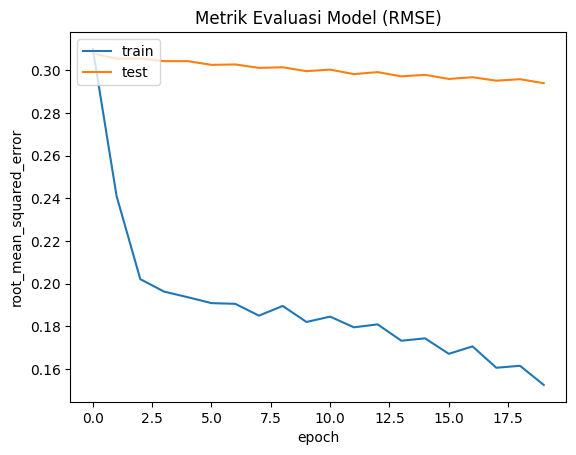

In [7]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('Metrik Evaluasi Model (RMSE)')
plt.ylabel('root_mean_squared_error')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## 8. Menguji Rekomendasi Collaborative Filtering
Mendapatkan rekomendasi buku untuk *User* tertentu berdasarkan prediksi rating dari model.

In [8]:
# Mengambil sample user
sample_user_id = df_collab['User-ID'].sample(1).iloc[0]
buku_dibaca_oleh_user = df_collab[df_collab['User-ID'] == sample_user_id]

# Mencari buku yang belum dibaca
buku_belum_dibaca = preparation[~preparation['ISBN'].isin(buku_dibaca_oleh_user['ISBN'].values)]['ISBN']
buku_belum_dibaca = list(set(buku_belum_dibaca).intersection(set(book_to_book_encoded.keys())))

buku_belum_dibaca_encoded = [[book_to_book_encoded.get(x)] for x in buku_belum_dibaca]
user_encoder = user_to_user_encoded.get(sample_user_id)
user_book_array = np.hstack(([[user_encoder]] * len(buku_belum_dibaca_encoded), buku_belum_dibaca_encoded))

# Prediksi model
ratings = model.predict(user_book_array).flatten()

# Mendapatkan top 5 rekomendasi
top_ratings_indices = ratings.argsort()[-5:][::-1]
recommended_book_ids = [book_encoded_to_book.get(buku_belum_dibaca_encoded[x][0]) for x in top_ratings_indices]

print(f"Rekomendasi untuk User ID: {sample_user_id}\n" + "-"*35)
recommended_books = preparation[preparation['ISBN'].isin(recommended_book_ids)]
display(recommended_books[['Book-Title', 'Book-Author', 'Publisher']])

267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Rekomendasi untuk User ID: 30487
-----------------------------------


,Book-Title,Book-Author,Publisher
221,The Five People You Meet in Heaven,Mitch Albom,Hyperion
225,Confessions of a Shopaholic (Summer Display Op...,SOPHIE KINSELLA,Delta
562,Good in Bed,Jennifer Weiner,Washington Square Press
1690,Plain Truth,Jodi Picoult,Washington Square Press
2215,To Kill a Mockingbird,Harper Lee,Little Brown &amp; Company
